In [1]:
# Did a lack of major third party support attribute to lower sales
# of games on the Wii U, especially when compared to the sales of
# games on other consoles released from 1980 to 2017?

## Importing Dataframe and Removing Unnecessary Columns

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

games_nan = pd.read_csv('Video_Games.csv', sep=',', header=0)

# Convert 'User_Score' and 'Critic_Score' to numeric, coercing errors and filling NaNs with 0
games_nan['User_Score'] = pd.to_numeric(games_nan['User_Score'], errors='coerce').fillna(0)
games_nan['Critic_Score'] = pd.to_numeric(games_nan['Critic_Score'], errors='coerce').fillna(0)

# Drop the 'Rating' and 'Developer' column
games_new = games_nan.drop('Rating', axis=1)
games_new_2 = games_new.drop('Developer', axis=1)

# Drop rows of games on more obscure columns or have incomplete data
games_filtered = games_new_2[games_new_2['Platform'] != 'GEN']
games_filtered_2 = games_filtered[games_filtered['Platform'] != 'DC']
games_filtered_3 = games_filtered_2[games_filtered_2['Platform'] != 'SCD']
games_filtered_4 = games_filtered_3[games_filtered_3['Platform'] != 'NG']
games_filtered_5 = games_filtered_4[games_filtered_4['Platform'] != 'WS']
games_filtered_6 = games_filtered_5[games_filtered_5['Platform'] != 'TG16']
games_filtered_7 = games_filtered_6[games_filtered_6['Platform'] != '3DO']
games_filtered_8 = games_filtered_7[games_filtered_7['Platform'] != 'GG']
games_filtered_9 = games_filtered_8[games_filtered_8['Platform'] != 'PCFX']

games_filtered_9.columns = games_filtered_9.columns.str.replace('Year_of_Release', 'Year of Release')
games_filtered_9.columns = games_filtered_9.columns.str.replace('NA_Sales', 'NA Sales')
games_filtered_9.columns = games_filtered_9.columns.str.replace('EU_Sales', 'EU Sales')
games_filtered_9.columns = games_filtered_9.columns.str.replace('JP_Sales', 'JP Sales')
games_filtered_9.columns = games_filtered_9.columns.str.replace('Other_Sales', 'Other Sales')
games_filtered_9.columns = games_filtered_9.columns.str.replace('Global_Sales', 'Global Sales')
games_filtered_9.columns = games_filtered_9.columns.str.replace('Critic_Score', 'Critic Score')
games_filtered_9.columns = games_filtered_9.columns.str.replace('Critic_Count', 'Critic Count')
games_filtered_9.columns = games_filtered_9.columns.str.replace('User_Score', 'User Score')
games_filtered_9.columns = games_filtered_9.columns.str.replace('User_Count', 'User Count')

# Fill remaining NaN values with 0 in the DataFrame
games = games_filtered_9.fillna(0)

In [3]:
games.head(10)

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,0.0,0.0,0.0,0.0
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,0.0,0.0,0.0,0.0
5,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,0.0,0.0,0.0,0.0
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,0.0,0.0,0.0,0.0


In [4]:
games.columns

Index(['Name', 'Platform', 'Year of Release', 'Genre', 'Publisher', 'NA Sales',
       'EU Sales', 'JP Sales', 'Other Sales', 'Global Sales', 'Critic Score',
       'Critic Count', 'User Score', 'User Count'],
      dtype='object')

## Adding Missing Values (according to Metacritic)

In [5]:
nintendo_count = games[(games['Publisher'] == 'Nintendo') & (games['Platform'] == 'WiiU')]
sony_count = games[(games['Publisher'] == 'Sony Computer Entertainment') & (games['Platform'] == 'PS4')]
microsoft_count = games[(games['Publisher'] == 'Microsoft Game Studios') & (games['Platform'] == 'XOne')]

In [6]:
games.loc[games['Name'] == 'Super Smash Bros. for Wii U and 3DS', 'Critic Score'] = 92
games.loc[games['Name'] == 'The Legend of Zelda: The Wind Waker', 'Critic Score'] = 90
games.loc[games['Name'] == 'Mario & Sonic at the Sochi 2014 Olympic Winter Games', 'Critic Score'] = 55
games.loc[games['Name'] == 'Monster Hunter Tri', 'Critic Score'] = 84
games.loc[games['Name'] == 'Mario & Sonic at the Rio 2016 Olympic Games', 'Critic Score'] = 60
games.loc[games['Name'] == 'Shin Megami Tensei x Fire Emblem', 'Critic Score'] = 80
games.loc[games['Name'] == 'Game & Wario', 'Critic Score'] = 61
games.loc[games['Name'] == 'Ninja Gaiden 3', 'Critic Score'] = 69
games.loc[games['Name'] == 'Just Dance Wii U', 'Critic Score'] = 80

games.loc[games['Name'] == 'Super Smash Bros. for Wii U and 3DS', 'User Score'] = 8.0
games.loc[games['Name'] == 'The Legend of Zelda: The Wind Waker', 'User Score'] = 9.0
games.loc[games['Name'] == 'Mario & Sonic at the Sochi 2014 Olympic Winter Games', 'User Score'] = 6.6
games.loc[games['Name'] == 'Monster Hunter Tri', 'User Score'] = 8.3
games.loc[games['Name'] == 'Mario & Sonic at the Rio 2016 Olympic Games', 'User Score'] = 6.4
games.loc[games['Name'] == 'Shin Megami Tensei x Fire Emblem', 'User Score'] = 7.9
games.loc[games['Name'] == 'Game & Wario', 'User Score'] = 6.9
games.loc[games['Name'] == 'Ninja Gaiden 3', 'User Score'] = 7.4
games.loc[games['Name'] == 'Just Dance Wii U', 'User Score'] = 8.0

games.loc[games['Name'] == 'Super Smash Bros. for Wii U and 3DS', 'Critic Count'] = 77
games.loc[games['Name'] == 'The Legend of Zelda: The Wind Waker', 'Critic Count'] = 70
games.loc[games['Name'] == 'Mario & Sonic at the Sochi 2014 Olympic Winter Games', 'Critic Count'] = 36
games.loc[games['Name'] == 'Monster Hunter Tri', 'Critic Count'] = 70
games.loc[games['Name'] == 'Mario & Sonic at the Rio 2016 Olympic Games', 'Critic Count'] = 30
games.loc[games['Name'] == 'Shin Megami Tensei x Fire Emblem', 'Critic Count'] = 62
games.loc[games['Name'] == 'Game & Wario', 'Critic Count'] = 60
games.loc[games['Name'] == 'Ninja Gaiden 3', 'Critic Count'] = 41
games.loc[games['Name'] == 'Just Dance Wii U', 'Critic Count'] = 8

games.loc[games['Name'] == 'Super Smash Bros. for Wii U and 3DS', 'User Count'] = 2353
games.loc[games['Name'] == 'The Legend of Zelda: The Wind Waker', 'User Count'] = 1610
games.loc[games['Name'] == 'Mario & Sonic at the Sochi 2014 Olympic Winter Games', 'User Count'] = 96
games.loc[games['Name'] == 'Monster Hunter Tri', 'User Count'] = 190
games.loc[games['Name'] == 'Mario & Sonic at the Rio 2016 Olympic Games', 'User Count'] = 78
games.loc[games['Name'] == 'Shin Megami Tensei x Fire Emblem', 'User Count'] = 394
games.loc[games['Name'] == 'Game & Wario', 'User Count'] = 151
games.loc[games['Name'] == 'Ninja Gaiden 3', 'User Count'] = 174
games.loc[games['Name'] == 'Just Dance Wii U', 'User Count'] = 8

nintendo_count = games[(games['Publisher'] == 'Nintendo') & (games['Platform'] == 'WiiU')]
nintendo_count.head(5)

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count
110,Mario Kart 8,WiiU,2014.0,Racing,Nintendo,3.15,2.15,1.28,0.51,7.09,88.0,82.0,9.1,1599.0
185,New Super Mario Bros. U,WiiU,2012.0,Platform,Nintendo,2.30,1.34,1.27,0.32,5.22,84.0,70.0,8.1,733.0
216,Super Smash Bros. for Wii U and 3DS,WiiU,2014.0,Fighting,Nintendo,2.60,1.08,0.81,0.38,4.87,92.0,77.0,8.0,2353.0
247,Splatoon,WiiU,2015.0,Shooter,Nintendo,1.54,1.18,1.46,0.26,4.43,81.0,88.0,8.5,1184.0
248,Nintendo Land,WiiU,2012.0,Misc,Nintendo,2.52,1.11,0.46,0.33,4.42,77.0,61.0,7.9,471.0


In [7]:
nintendo_zero = nintendo_count[nintendo_count['Critic Score'] == 0]
nintendo_zero

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count


In [8]:
sony_zero = sony_count[sony_count['Critic Score'] == 0]
sony_zero

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count
225,The Last of Us,PS4,2014.0,Action,Sony Computer Entertainment,1.88,2.00,0.07,0.77,4.71,0.0,0.0,0.0,0.0
1216,Ratchet & Clank (2016),PS4,2016.0,Platform,Sony Computer Entertainment,0.50,0.76,0.04,0.24,1.54,0.0,0.0,0.0,0.0
2332,MLB 16: The Show,PS4,2016.0,Action,Sony Computer Entertainment,0.72,0.00,0.00,0.17,0.89,0.0,0.0,0.0,0.0
3126,God of War III,PS4,2015.0,Action,Sony Computer Entertainment,0.24,0.29,0.01,0.10,0.65,0.0,0.0,0.0,0.0
7579,The Heavy Rain and Beyond: Two Souls Collection,PS4,2016.0,Action,Sony Computer Entertainment,0.00,0.17,0.00,0.03,0.20,0.0,0.0,0.0,0.0


In [9]:
games.loc[games['Name'] == 'The Last of Us', 'Critic Score'] = 95
games.loc[games['Name'] == 'Ratchet & Clank (2016)', 'Critic Score'] = 85
games.loc[games['Name'] == 'MLB 16: The Show', 'Critic Score'] = 85
games.loc[games['Name'] == 'God of War III', 'Critic Score'] = 92
games.loc[games['Name'] == 'The Heavy Rain and Beyond: Two Souls Collection', 'Critic Score'] = 78

games.loc[games['Name'] == 'The Last of Us', 'User Score'] = 9.2
games.loc[games['Name'] == 'Ratchet & Clank (2016)', 'User Score'] = 8.3
games.loc[games['Name'] == 'MLB 16: The Show', 'User Score'] = 7.3
games.loc[games['Name'] == 'God of War III', 'User Score'] = 9.0
games.loc[games['Name'] == 'The Heavy Rain and Beyond: Two Souls Collection', 'User Score'] = 8.4

games.loc[games['Name'] == 'The Last of Us', 'Critic Count'] = 95
games.loc[games['Name'] == 'Ratchet & Clank (2016)', 'Critic Count'] = 85
games.loc[games['Name'] == 'MLB 16: The Show', 'Critic Count'] = 85
games.loc[games['Name'] == 'God of War III', 'Critic Count'] = 92
games.loc[games['Name'] == 'The Heavy Rain and Beyond: Two Souls Collection', 'Critic Count'] = 78

games.loc[games['Name'] == 'The Last of Us', 'User ount'] = 9.2
games.loc[games['Name'] == 'Ratchet & Clank (2016)', 'User Count'] = 8.3
games.loc[games['Name'] == 'MLB 16: The Show', 'User Count'] = 7.3
games.loc[games['Name'] == 'God of War III', 'User Count'] = 9.0
games.loc[games['Name'] == 'The Heavy Rain and Beyond: Two Souls Collection', 'User Count'] = 8.4

sony_count = games[(games['Publisher'] == 'Sony Computer Entertainment') & (games['Platform'] == 'PS4')]
sony_count.head(5)

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count,User ount
171,Uncharted 4: A Thief's End,PS4,2016.0,Shooter,Sony Computer Entertainment,1.85,2.50,0.19,0.85,5.38,93.0,113.0,7.9,7064.0,NaN
225,The Last of Us,PS4,2014.0,Action,Sony Computer Entertainment,1.88,2.00,0.07,0.77,4.71,95.0,95.0,9.2,0.0,9.2
231,Uncharted: The Nathan Drake Collection,PS4,2015.0,Action,Sony Computer Entertainment,2.07,1.71,0.08,0.76,4.62,86.0,78.0,8.1,1264.0,NaN
529,inFAMOUS: Second Son,PS4,2014.0,Action,Sony Computer Entertainment,1.28,0.98,0.07,0.46,2.79,80.0,90.0,7.9,2944.0,NaN
560,Killzone: Shadow Fall,PS4,2013.0,Shooter,Sony Computer Entertainment,0.89,1.33,0.08,0.39,2.69,73.0,88.0,6.8,2102.0,NaN


In [10]:
microsoft_zero = microsoft_count[microsoft_count['Critic Score'] == 0]
microsoft_zero

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count
543,Minecraft,XOne,2014.0,Misc,Microsoft Game Studios,1.61,0.90,0.0,0.25,2.76,0.0,0.0,0.0,0.0
5190,Zoo Tycoon (2013),XOne,2013.0,Simulation,Microsoft Game Studios,0.18,0.15,0.0,0.03,0.36,0.0,0.0,0.0,0.0
7417,State of Decay,XOne,2015.0,Strategy,Microsoft Game Studios,0.14,0.05,0.0,0.02,0.21,0.0,0.0,0.0,0.0
11773,Killer Instinct (2013),XOne,2013.0,Fighting,Microsoft Game Studios,0.04,0.03,0.0,0.01,0.07,0.0,0.0,0.0,0.0


In [11]:
games.loc[games['Name'] == 'Minecraft', 'Critic Score'] = 88
games.loc[games['Name'] == 'Zoo Tycoon (2013)', 'Critic Score'] = 68
games.loc[games['Name'] == 'State of Decay', 'Critic Score'] = 78
games.loc[games['Name'] == 'Killer Instinct (2013)', 'Critic Score'] = 73

games.loc[games['Name'] == 'Minecraft', 'User Score'] = 8.4
games.loc[games['Name'] == 'Zoo Tycoon (2013)', 'User Score'] = 4.0
games.loc[games['Name'] == 'State of Decay', 'User Score'] = 7.8
games.loc[games['Name'] == 'Killer Instinct (2013)', 'User Score'] = 6.6

games.loc[games['Name'] == 'Minecraft', 'Critic Count'] = 88
games.loc[games['Name'] == 'Zoo Tycoon (2013)', 'Critic Count'] = 68
games.loc[games['Name'] == 'State of Decay', 'Critic Count'] = 78
games.loc[games['Name'] == 'Killer Instinct (2013)', 'Critic Count'] = 73

games.loc[games['Name'] == 'Minecraft', 'User Count'] = 8.4
games.loc[games['Name'] == 'Zoo Tycoon (2013)', 'User Count'] = 4.0
games.loc[games['Name'] == 'State of Decay', 'User Count'] = 7.8
games.loc[games['Name'] == 'Killer Instinct (2013)', 'User Count'] = 6.6

microsoft_count = games[(games['Publisher'] == 'Microsoft Game Studios') & (games['Platform'] == 'XOne')]
microsoft_count.head(5)

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count,User ount
242,Halo 5: Guardians,XOne,2015.0,Shooter,Microsoft Game Studios,2.78,1.27,0.03,0.41,4.48,84.0,101.0,6.4,2438.0,NaN
413,Gears of War: Ultimate Edition,XOne,2015.0,Shooter,Microsoft Game Studios,2.61,0.33,0.00,0.34,3.28,82.0,74.0,7.5,563.0,NaN
422,Halo: The Master Chief Collection,XOne,2014.0,Shooter,Microsoft Game Studios,1.91,1.00,0.03,0.29,3.23,85.0,69.0,7.2,1267.0,NaN
543,Minecraft,XOne,2014.0,Misc,Microsoft Game Studios,1.61,0.90,0.00,0.25,2.76,88.0,88.0,8.4,8.4,NaN
738,Forza Motorsport 5,XOne,2013.0,Racing,Microsoft Game Studios,1.21,0.79,0.01,0.19,2.20,79.0,76.0,5.9,1095.0,NaN


## Organizing Games By Platform

In [12]:
wiiu = games[games['Platform'] == 'WiiU']
ps4 = games[games['Platform'] == 'PS4']
xone = games[games['Platform'] == 'XOne']

global_sales = games.groupby('Platform')['Global Sales'].sum().reset_index()
sorted_global_sales = global_sales.sort_values(by='Global Sales', ascending=False)
filtered_global_sales = global_sales[global_sales['Platform'].isin(['WiiU', 'XOne', 'PS4'])]

## Visualization Options

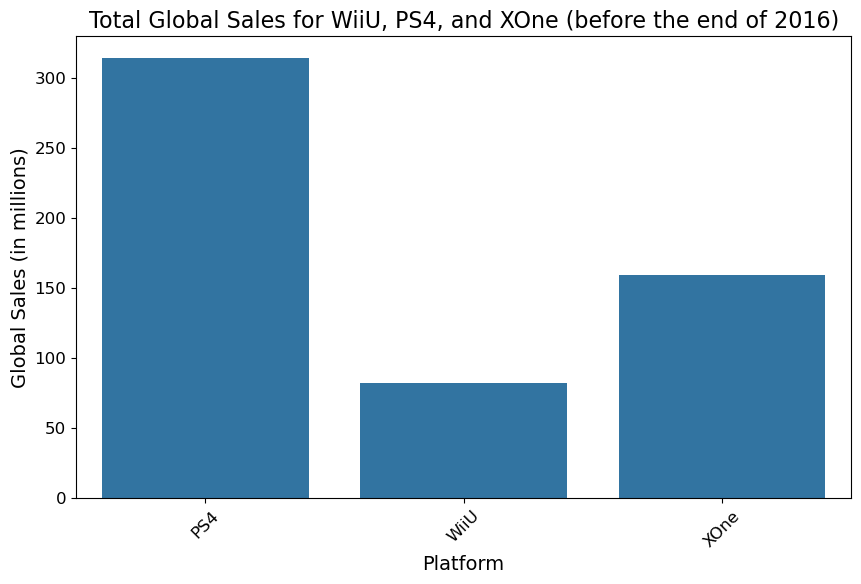

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=filtered_global_sales, x='Platform', y='Global Sales')
plt.title('Total Global Sales for WiiU, PS4, and XOne (before the end of 2016)', fontsize=16)
plt.xlabel('Platform', fontsize=14)
plt.ylabel('Global Sales (in millions)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Total Global Sales for WiiU, PS4, and XOne (before the end of 2016)', transparent=True, bbox_inches='tight')
plt.show()


In [14]:
nintendo_global_sales = global_sales[global_sales['Platform'].isin(['NES', 'SNES', 'N64', 'GC', 'Wii', 'WiiU', 'GB', 'GBA', 'DS', '3DS'])].sort_values(by='Global Sales', ascending=False)
nintendo_global_sales

,Platform,Global Sales
17,Wii,908.13
2,DS,807.10
4,GBA,318.50
1,3DS,259.09
3,GB,255.45
7,NES,251.07
6,N64,218.88
16,SNES,200.05
5,GC,199.36
18,WiiU,82.16


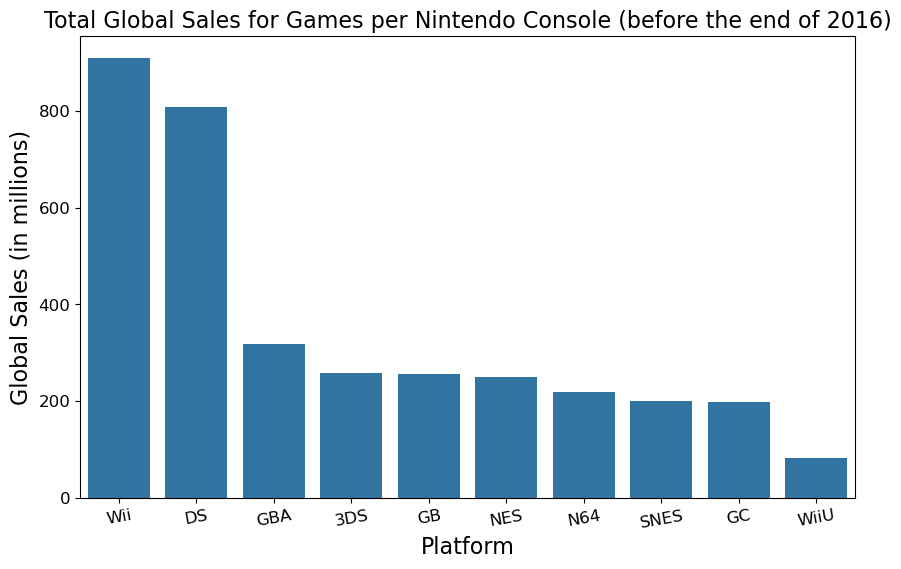

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=nintendo_global_sales, x='Platform', y='Global Sales')
plt.title('Total Global Sales for Games per Nintendo Console (before the end of 2016)', fontsize=16)
plt.xlabel('Platform', fontsize=16)
plt.ylabel('Global Sales (in millions)', fontsize=16)
plt.xticks(rotation=10, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Total Global Sales for Games per Nintendo Console (before the end of 2016)', transparent=True)
plt.show()

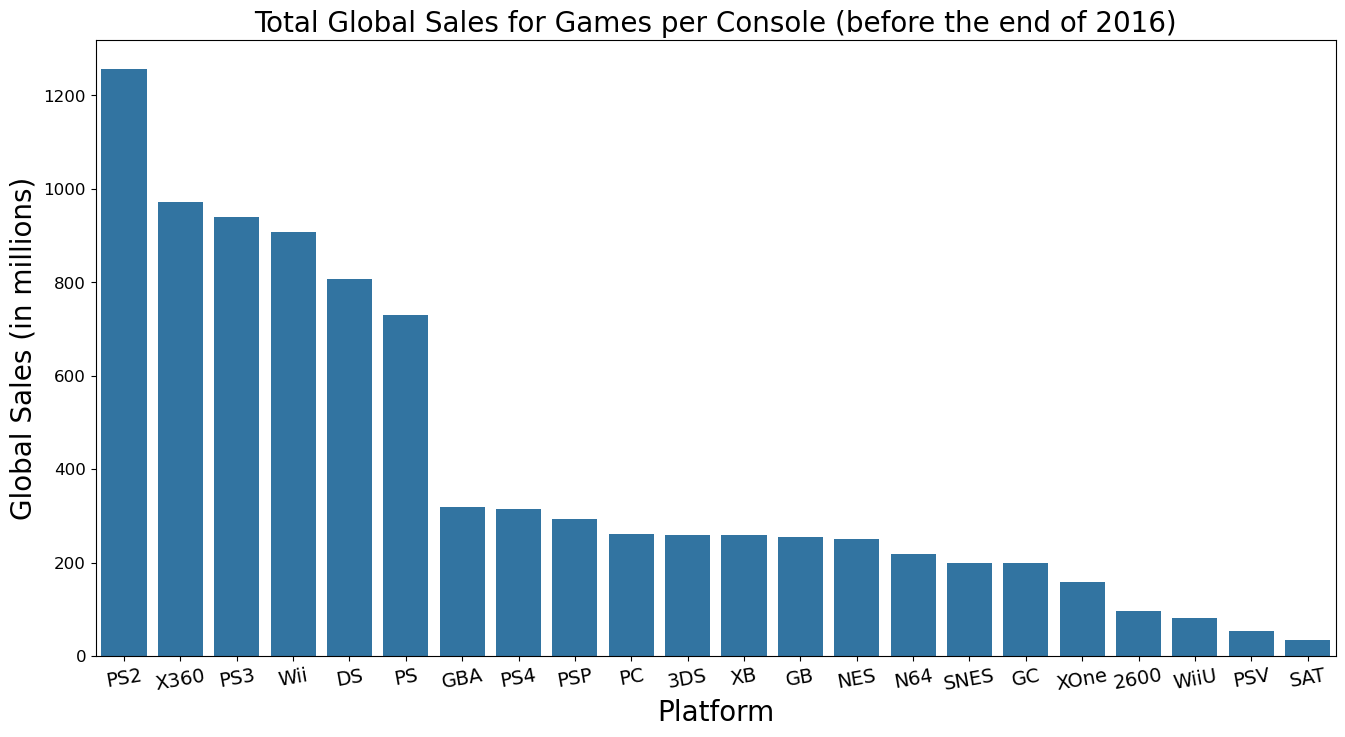

In [61]:
plt.figure(figsize=(16, 8))
sns.barplot(data=sorted_global_sales, x='Platform', y='Global Sales')
plt.title('Total Global Sales for Games per Console (before the end of 2016)', fontsize=20)
plt.xlabel('Platform', fontsize=20)
plt.ylabel('Global Sales (in millions)', fontsize=20)
plt.xticks(rotation=10, fontsize=14)
plt.yticks(fontsize=12)
plt.savefig('Total Global Sales for Games per Console (before the end of 2016)', transparent=True)
plt.show()

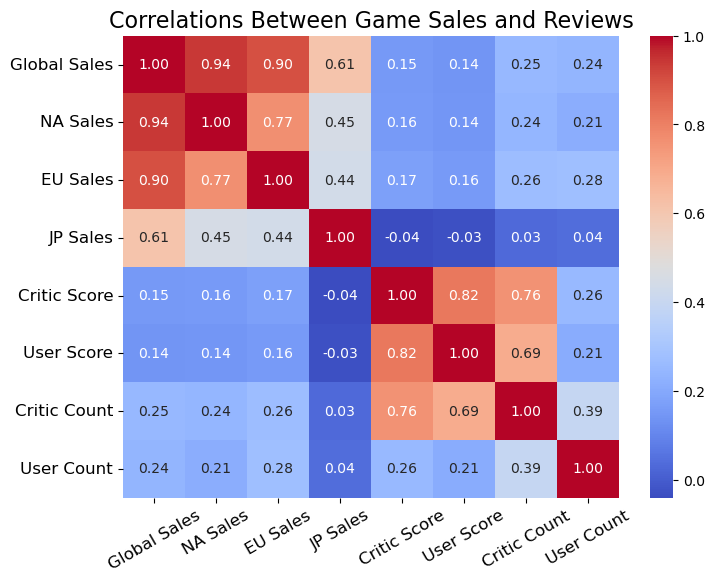

In [17]:
# Prepare data for correlation
correlation_data = games[['Global Sales', 'NA Sales', 'EU Sales', 'JP Sales', 'Critic Score', 'User Score', 'Critic Count', 'User Count']]
correlation_matrix = correlation_data.corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
plt.title('Correlations Between Game Sales and Reviews', fontsize=16)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Correlations Between Game Sales and Reviews', transparent=True, bbox_inches='tight')
plt.show()

## Comparing Games By Publisher

In [18]:
activision = games[games['Publisher'] == 'Activision']
activision_games = activision[['Name', 'Platform', 'Publisher', 'Global Sales']]
activision_ps4 = activision_games[activision_games['Platform'] == 'PS4']
activision_XOne = activision_games[activision_games['Platform'] == 'XOne']
activision_WiiU = activision_games[activision_games['Platform'] == 'WiiU']

taketwo = games[games['Publisher'] == 'Take-Two Interactive']
taketwo_games = taketwo[['Name', 'Platform', 'Publisher', 'Global Sales']]
taketwo_ps4 = taketwo_games[taketwo_games['Platform'] == 'PS4']
taketwo_XOne = taketwo_games[taketwo_games['Platform'] == 'XOne']
taketwo_WiiU = taketwo_games[taketwo_games['Platform'] == 'WiiU']

bethesda = games[games['Publisher'] == 'Bethesda Softworks']
bethesda_games = bethesda[['Name', 'Platform', 'Publisher', 'Global Sales']]
bethesda_ps4 = bethesda_games[bethesda_games['Platform'] == 'PS4']
bethesda_XOne = bethesda_games[bethesda_games['Platform'] == 'XOne']
bethesda_WiiU = bethesda_games[bethesda_games['Platform'] == 'WiiU']

ea = games[games['Publisher'] == 'Electronic Arts']
ea_games = ea[['Name', 'Platform', 'Publisher', 'Global Sales']]
ea_ps4 = ea_games[ea_games['Platform'] == 'PS4']
 = ea_games[ea_games['Platform'] == 'XOne']
ea_WiiU = ea_games[ea_games['Platform'] == 'WiiU']

ubisoft = games[games['Publisher'] == 'Ubisoft']
ubisoft_games = ubisoft[['Name', 'Platform', 'Publisher', 'Global Sales']]
ubisoft_ps4 = ubisoft_games[ubisoft_games['Platform'] == 'PS4']
ubisoft_XOne = ubisoft_games[ubisoft_games['Platform'] == 'XOne']
ubisoft_WiiU = ubisoft_games[ubisoft_games['Platform'] == 'WiiU']

capcom = games[games['Publisher'] == 'Capcom']
capcom_games = capcom[['Name', 'Platform', 'Publisher', 'Global Sales']]
capcom_ps4 = capcom_games[capcom_games['Platform'] == 'PS4']
capcom_XOne = capcom_games[capcom_games['Platform'] == 'XOne']
capcom_WiiU = capcom_games[capcom_games['Platform'] == 'WiiU']

sega = games[games['Publisher'] == 'Sega']
sega_games = sega[['Name', 'Platform', 'Publisher', 'Global Sales']]
sega_ps4 = sega_games[sega_games['Platform'] == 'PS4']
sega_XOne = sega_games[sega_games['Platform'] == 'XOne']
sega_WiiU = sega_games[sega_games['Platform'] == 'WiiU']

## Visualizing Games By Publisher

In [57]:
print(ea_ps4.shape)
print(ea_XOne.shape)
print(ea_WiiU.shape)

(28, 4)
(29, 4)
(4, 4)


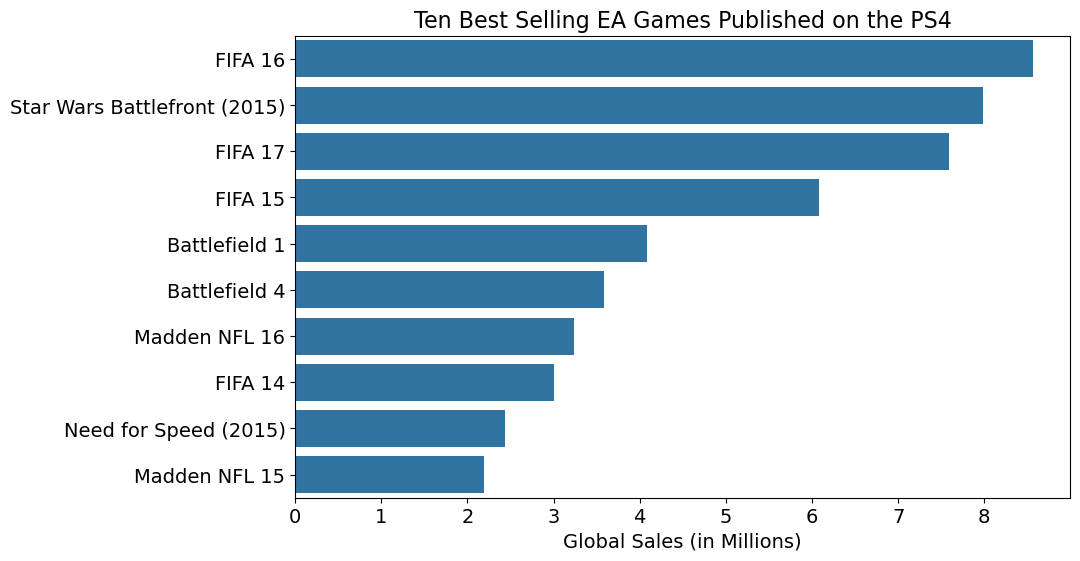

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x=ea_ps4['Global Sales'], y=ea_ps4['Name'].head(10))
plt.title('Ten Best Selling EA Games Published on the PS4', fontsize=16)
plt.xlabel('Global Sales (in Millions)', fontsize=14)
plt.ylabel('')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig('Ten Best Selling EA Games Published on the PS4', transparent=True, bbox_inches='tight')
plt.show()

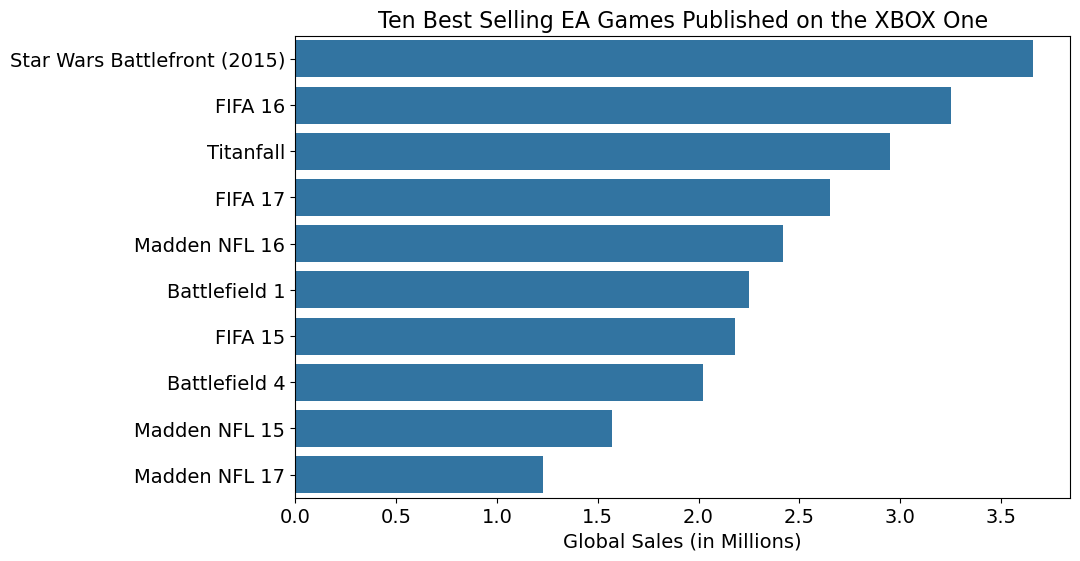

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x=ea_XOne['Global Sales'], y=ea_XOne['Name'].head(10))
plt.title('Ten Best Selling EA Games Published on the XBOX One', fontsize=16)
plt.xlabel('Global Sales (in Millions)', fontsize=14)
plt.ylabel('')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig('Ten Best Selling EA Games Published on the XBOX One', transparent=True, bbox_inches='tight')
plt.show()

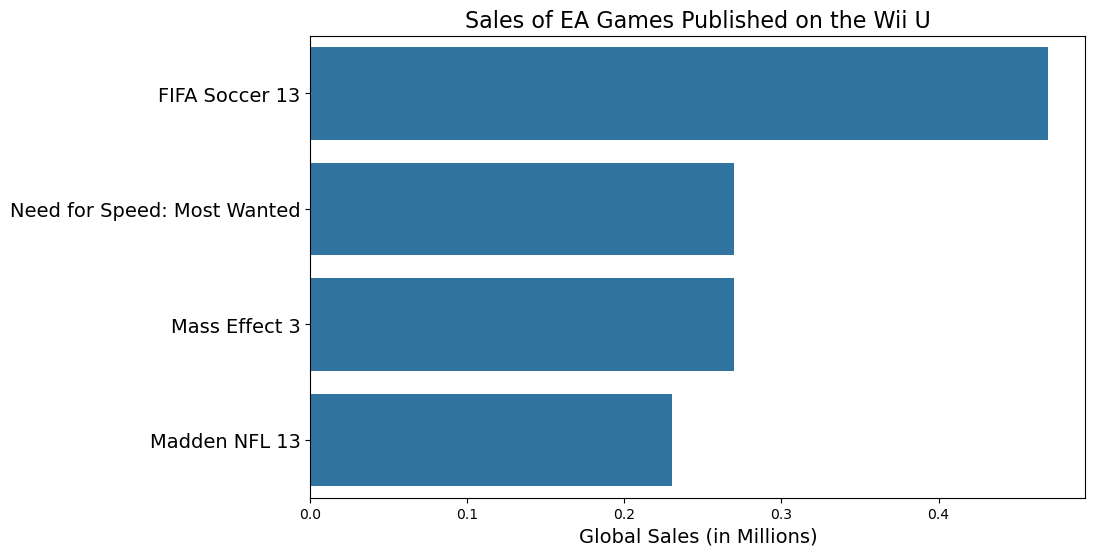

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x=ea_WiiU['Global Sales'], y=ea_WiiU['Name'])
plt.title('Sales of EA Games Published on the Wii U', fontsize=16)
plt.xlabel('Global Sales (in Millions)', fontsize=14)
plt.ylabel('')
plt.yticks(fontsize=14)
plt.savefig('Sales of EA Games Published on the Wii U', transparent=True, bbox_inches='tight')
plt.show()

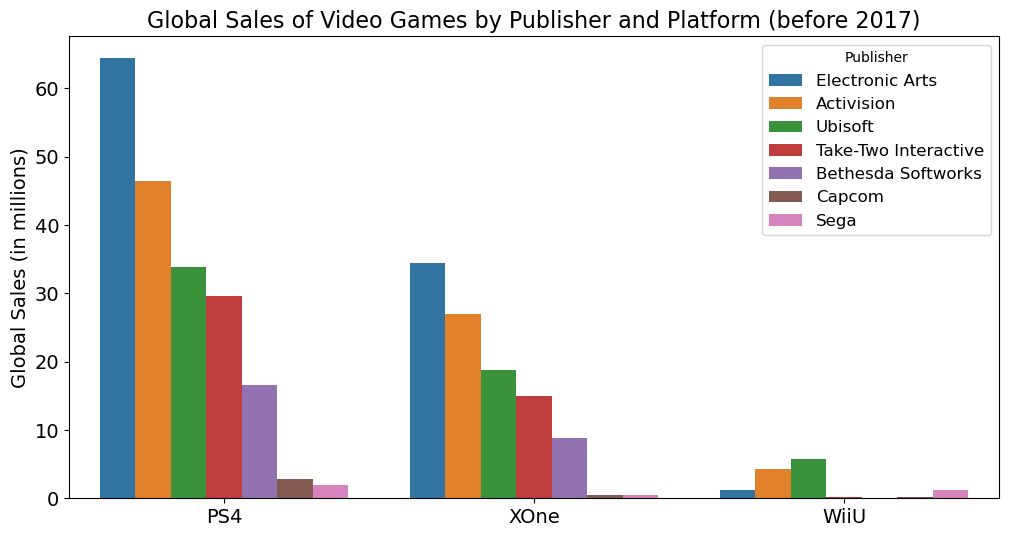

In [22]:
publishers = ['Electronic Arts', 'Activision', 'Ubisoft', 'Take-Two Interactive', 'Bethesda Softworks', 'Capcom', 'Sega']
filtered_games = games[games['Publisher'].isin(publishers)]

desired_platforms = ['PS4', 'XOne', 'WiiU']
filtered_games = filtered_games[filtered_games['Platform'].isin(desired_platforms)]

grouped_data = filtered_games.groupby(['Publisher', 'Platform'], as_index=False)['Global Sales'].sum()

grouped_data['Platform'] = pd.Categorical(grouped_data['Platform'], categories=desired_platforms, ordered=True)
grouped_data['Publisher'] = pd.Categorical(grouped_data['Publisher'], categories=publishers, ordered=True)

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_data, x='Platform', y='Global Sales', hue='Publisher')
plt.title('Global Sales of Video Games by Publisher and Platform (before 2017)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.ylabel('Global Sales (in millions)', fontsize=14)
plt.legend(title='Publisher', fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig('Global Sales of Video Games by Publisher and Platform (before 2017)', transparent=True, bbox_inches='tight')
plt.show()

## Visualizing Data Comparing Nintendo (Wii U), Sony (PS4) and Microsoft (XBOX One) Games

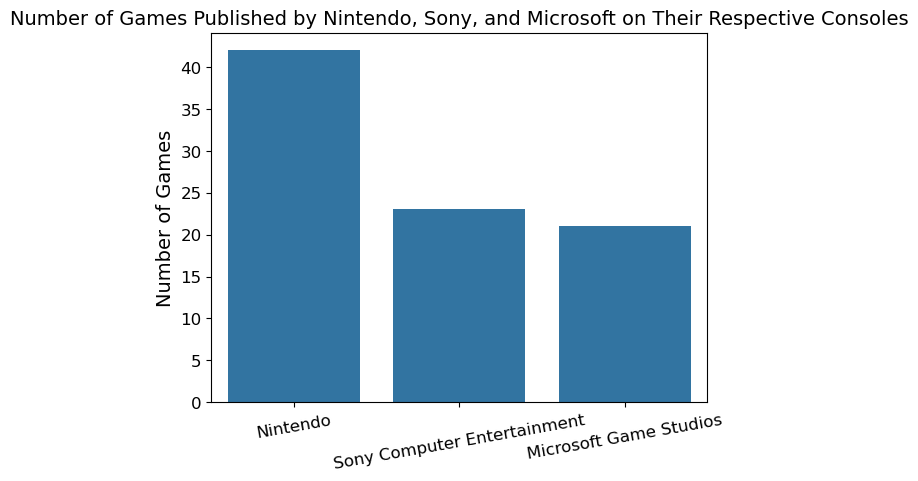

In [23]:
publishers_2 = ['Nintendo', 'Sony Computer Entertainment', 'Microsoft Game Studios']
counts_2 = [nintendo_count.shape[0], sony_count.shape[0], microsoft_count.shape[0]]

sns.barplot(x=publishers_2, y=counts_2)
plt.title('Number of Games Published by Nintendo, Sony, and Microsoft on Their Respective Consoles', fontsize=14)
plt.xlabel('')
plt.ylabel('Number of Games', fontsize=14)
plt.xticks(rotation=10, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Number of Games Published by Nintendo, Sony, and Microsoft on Their Respective Consoles', transparent=True, bbox_inches='tight')
plt.show()

In [24]:
nintendo_sales = nintendo_count['Global Sales'].sum()
sony_sales = sony_count['Global Sales'].sum()
microsoft_sales = microsoft_count['Global Sales'].sum()

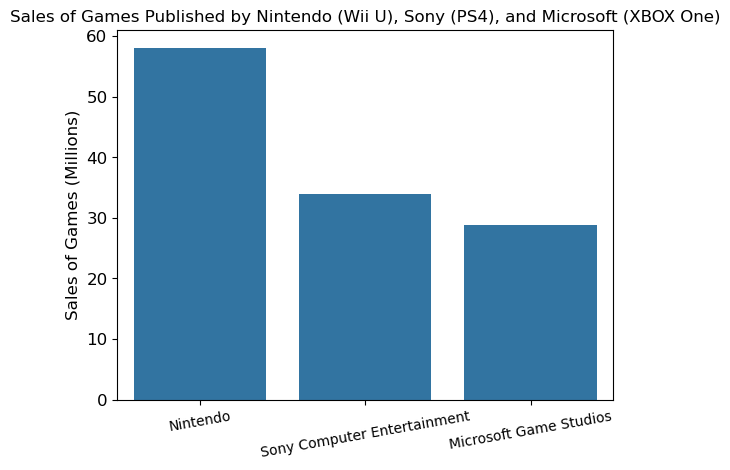

In [25]:
publishers_2 = ['Nintendo', 'Sony Computer Entertainment', 'Microsoft Game Studios']
counts_3 = [nintendo_sales, sony_sales, microsoft_sales]

sns.barplot(x=publishers_2, y=counts_3)
plt.title('Sales of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XBOX One)')
plt.xlabel('')
plt.ylabel('Sales of Games (Millions)', fontsize=12)
plt.xticks(rotation=10)
plt.yticks(fontsize=12)
plt.savefig('Sales of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XBOX One)', transparent=True)
plt.show()

In [26]:
nintendo_reviews = nintendo_count['Critic Score'].mean()
nintendo_reviews_user = nintendo_count['User Score'].mean()

In [27]:
sony_reviews = sony_count['Critic Score'].mean()
sony_reviews_user = sony_count['User Score'].mean()

In [28]:
microsoft_reviews = microsoft_count['Critic Score'].mean()
microsoft_reviews_user = microsoft_count['User Score'].mean()

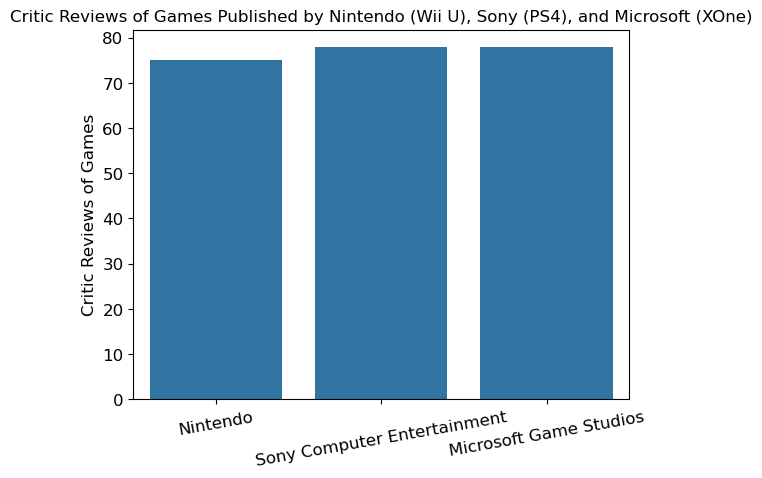

In [29]:
publishers_2 = ['Nintendo', 'Sony Computer Entertainment', 'Microsoft Game Studios']
counts_4 = [nintendo_reviews, sony_reviews, microsoft_reviews]

sns.barplot(x=publishers_2, y=counts_4)
plt.title('Critic Reviews of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XOne)')
plt.xlabel('')
plt.ylabel('Critic Reviews of Games', fontsize=12)
plt.xticks(rotation=10, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Critic Reviews of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XOne)', transparent=True, bbox_inches='tight')
plt.show()

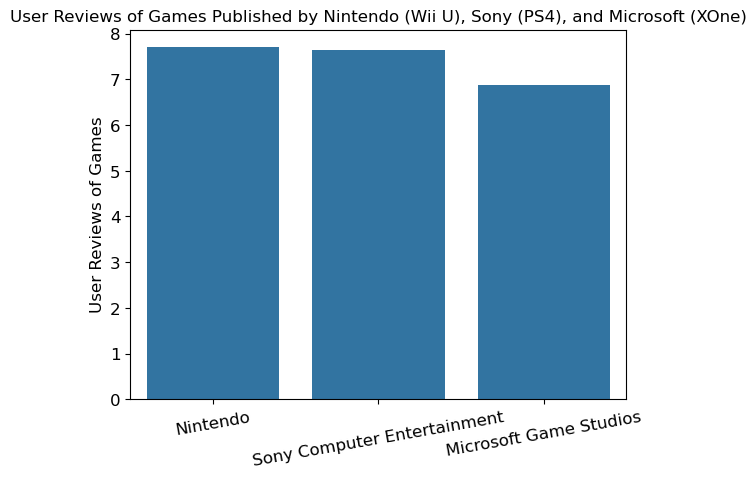

In [30]:
publishers_2 = ['Nintendo', 'Sony Computer Entertainment', 'Microsoft Game Studios']
counts_5 = [nintendo_reviews_user, sony_reviews_user, microsoft_reviews_user]

sns.barplot(x=publishers_2, y=counts_5)
plt.title('User Reviews of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XOne)')
plt.xlabel('')
plt.ylabel('User Reviews of Games', fontsize=12)
plt.xticks(rotation=10, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('User Reviews of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XOne)', transparent=True, bbox_inches='tight')
plt.show()

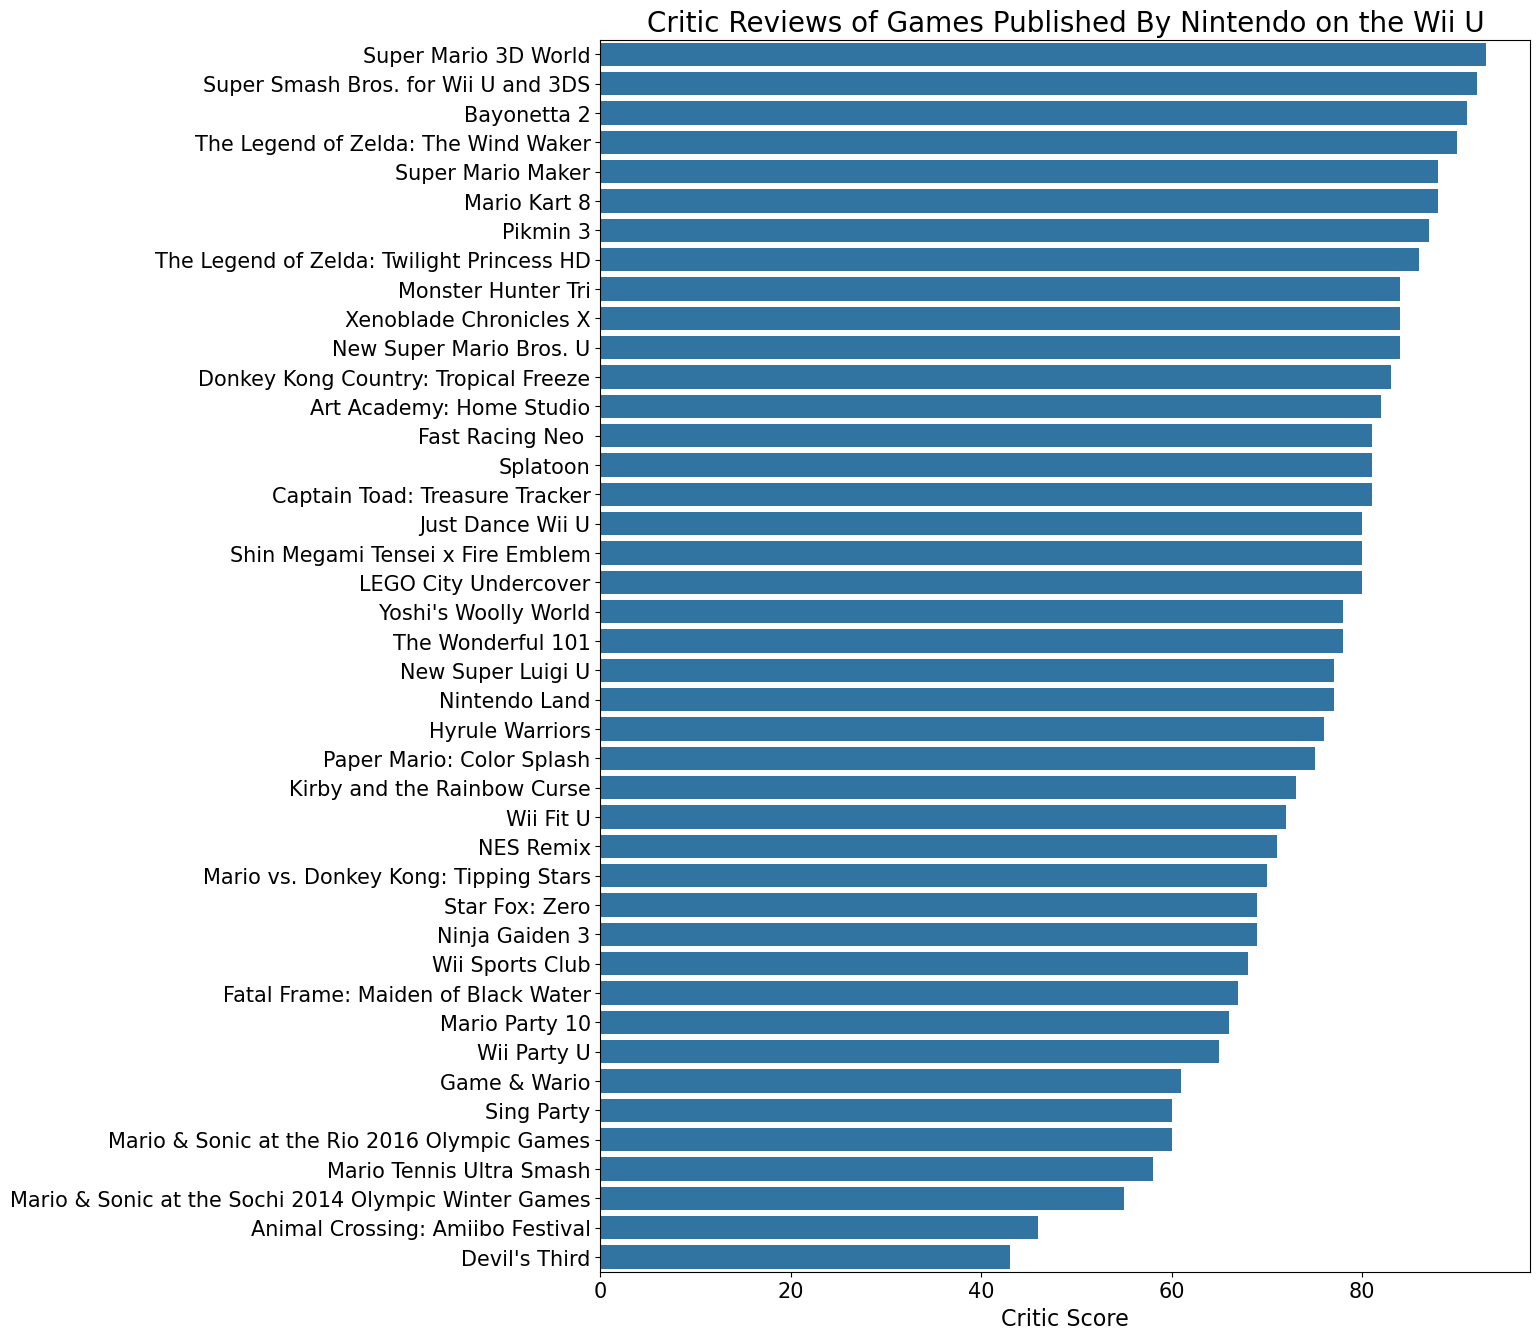

In [31]:
nintendo_reviews_2 = nintendo_count.sort_values(by='Critic Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 16))
sns.barplot(x=nintendo_reviews_2['Critic Score'], y=nintendo_reviews_2['Name'])
plt.title('Critic Reviews of Games Published By Nintendo on the Wii U', fontsize=20)
plt.xlabel('Critic Score', fontsize=16)
plt.ylabel('')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig('Critic Reviews of Games Published By Nintendo on the Wii U', transparent=True, bbox_inches='tight')
plt.show()

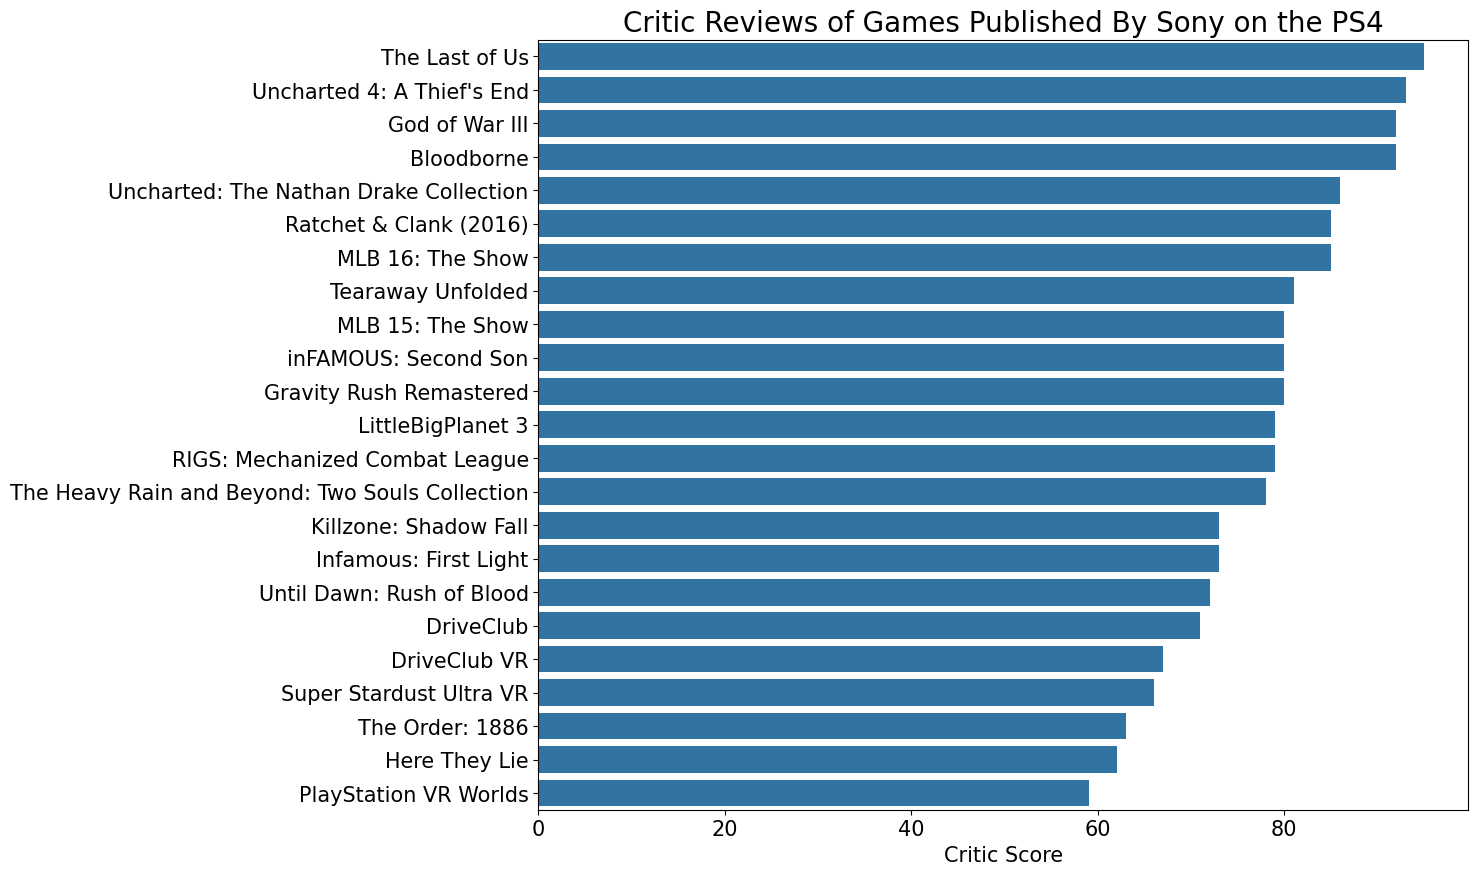

In [32]:
sony_reviews_2 = sony_count.sort_values(by='Critic Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 10))
sns.barplot(x=sony_reviews_2['Critic Score'], y=sony_reviews_2['Name'])
plt.title('Critic Reviews of Games Published By Sony on the PS4', fontsize=20)
plt.xlabel('Critic Score', fontsize=15)
plt.ylabel('')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig('Critic Reviews of Games Published By Sony on the PS4', transparent=True, bbox_inches='tight')
plt.show()

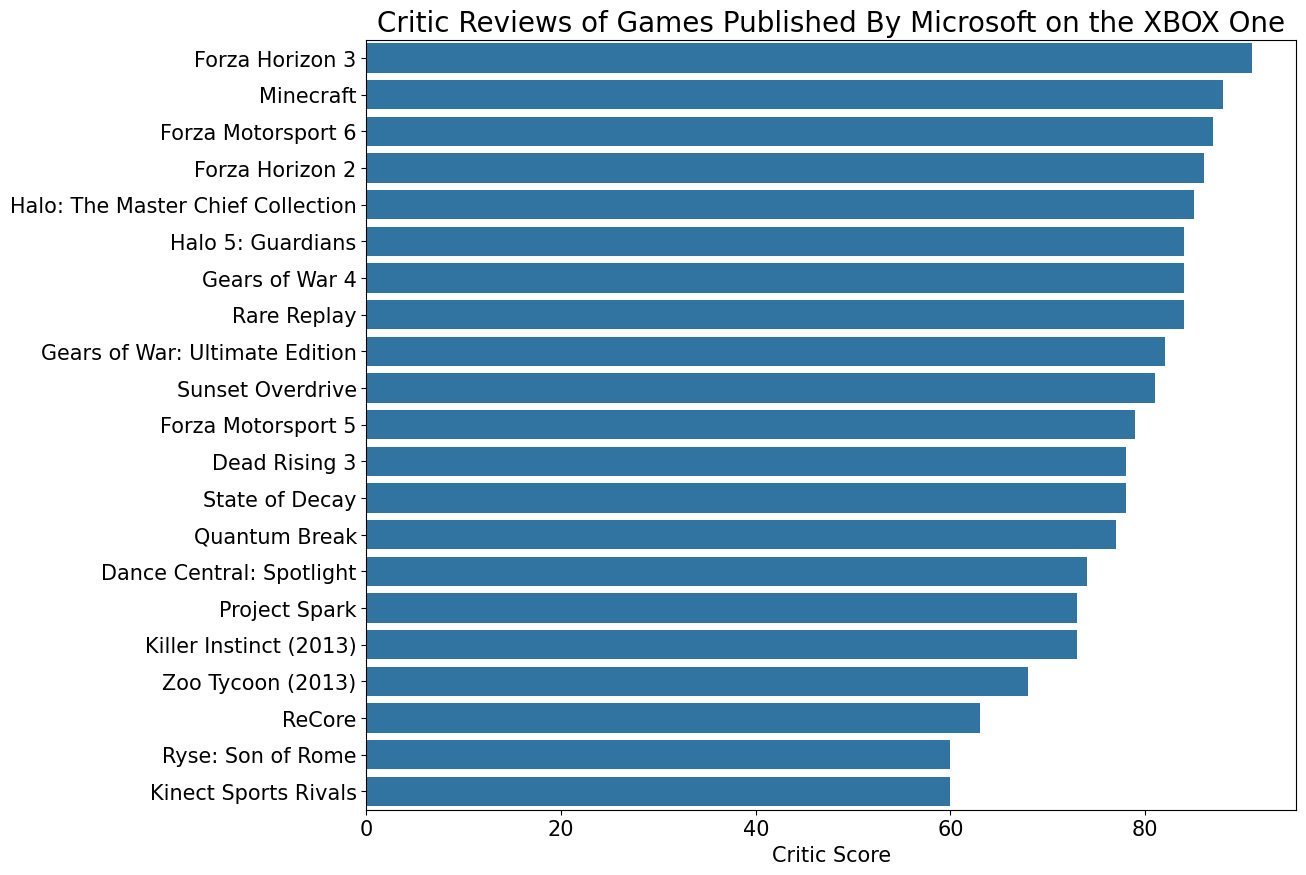

In [72]:
microsoft_reviews_2 = microsoft_count.sort_values(by='Critic Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 10))
sns.barplot(x=microsoft_reviews_2['Critic Score'], y=microsoft_reviews_2['Name'])
plt.title('Critic Reviews of Games Published By Microsoft on the XBOX One', fontsize=20)
plt.xlabel('Critic Score', fontsize=15)
plt.ylabel('')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig('Critic Reviews of Games Published By Microsoft on the XBOX One', transparent=True, bbox_inches='tight')
plt.show()

C:\Users\joshp\AppData\Local\Temp\ipykernel_24700\500669671.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nintendo_count['User_Score'] = pd.to_numeric(nintendo_count['User Score'], errors='coerce')


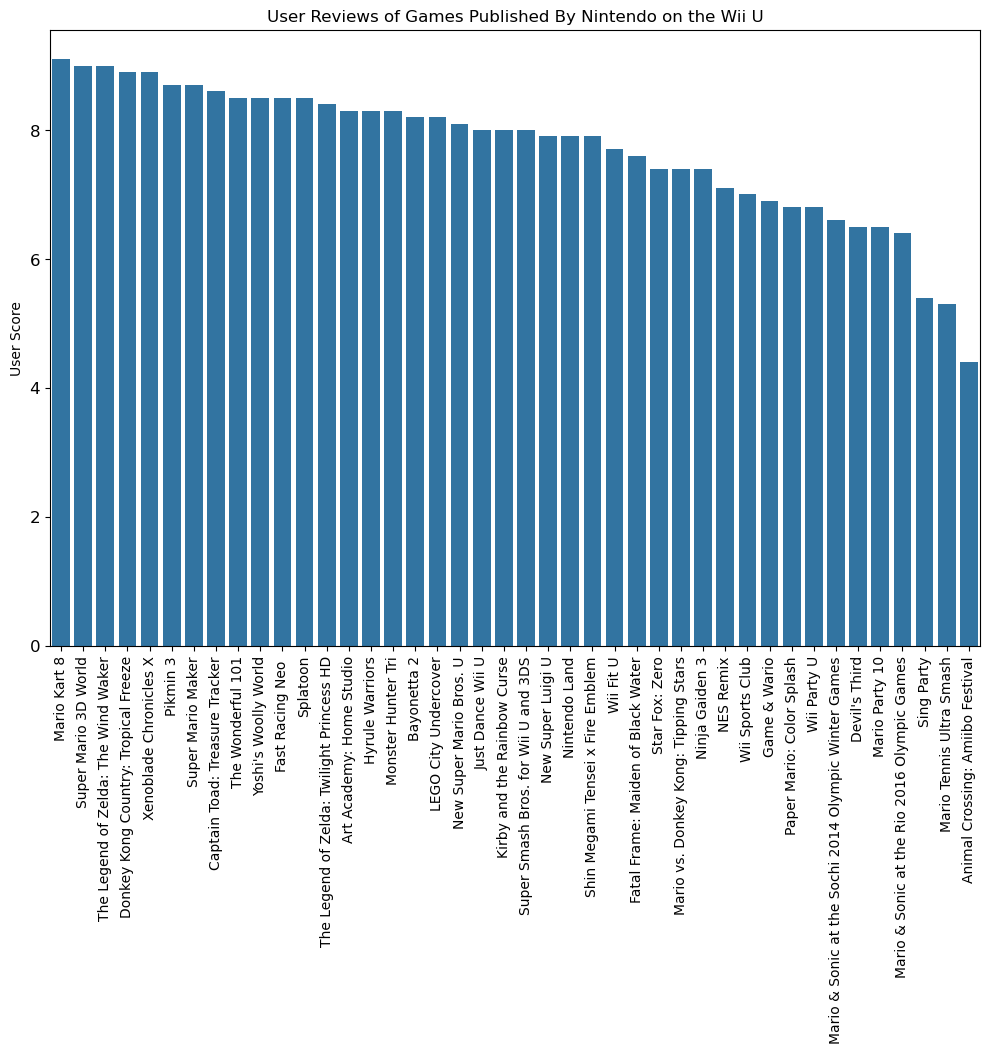

In [36]:
nintendo_count['User_Score'] = pd.to_numeric(nintendo_count['User Score'], errors='coerce')

nintendo_reviews_3 = nintendo_count.sort_values(by='User_Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 8))
sns.barplot(x=nintendo_reviews_3['Name'], y=nintendo_reviews_3['User Score'])
plt.title('User Reviews of Games Published By Nintendo on the Wii U')
plt.xlabel('')
plt.ylabel('User Score')
plt.xticks(rotation=90)
plt.yticks(fontsize=12)
plt.show()

C:\Users\joshp\AppData\Local\Temp\ipykernel_24700\3747456038.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sony_count['User_Score'] = pd.to_numeric(sony_count['User Score'], errors='coerce')


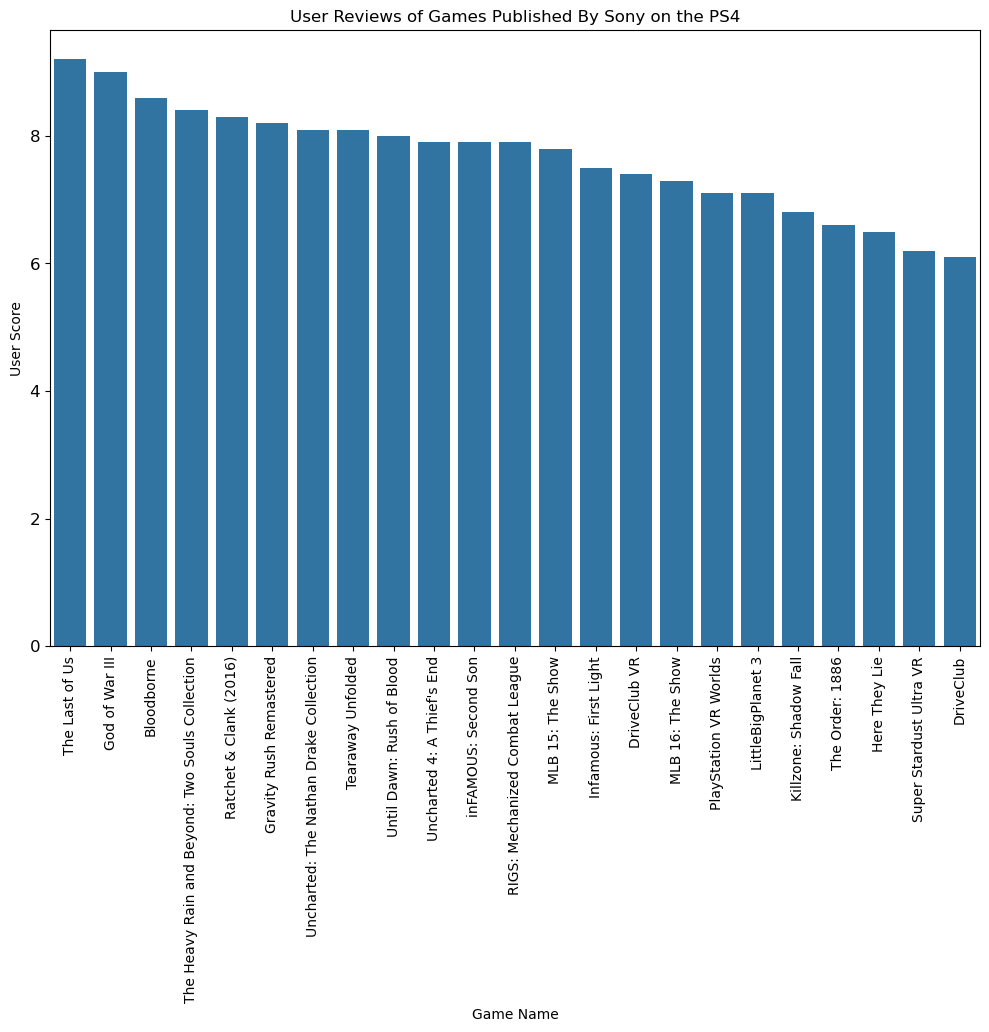

In [37]:
sony_count['User_Score'] = pd.to_numeric(sony_count['User Score'], errors='coerce')

sony_reviews_3 = sony_count.sort_values(by='User Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 8))
sns.barplot(x=sony_reviews_3['Name'], y=sony_reviews_3['User Score'])
plt.title('User Reviews of Games Published By Sony on the PS4')
plt.xlabel('Game Name')
plt.ylabel('User Score')
plt.xticks(rotation=90)
plt.yticks(fontsize=12)
plt.show()

C:\Users\joshp\AppData\Local\Temp\ipykernel_24700\1497934142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  microsoft_count['User Score'] = pd.to_numeric(microsoft_count['User Score'], errors='coerce')


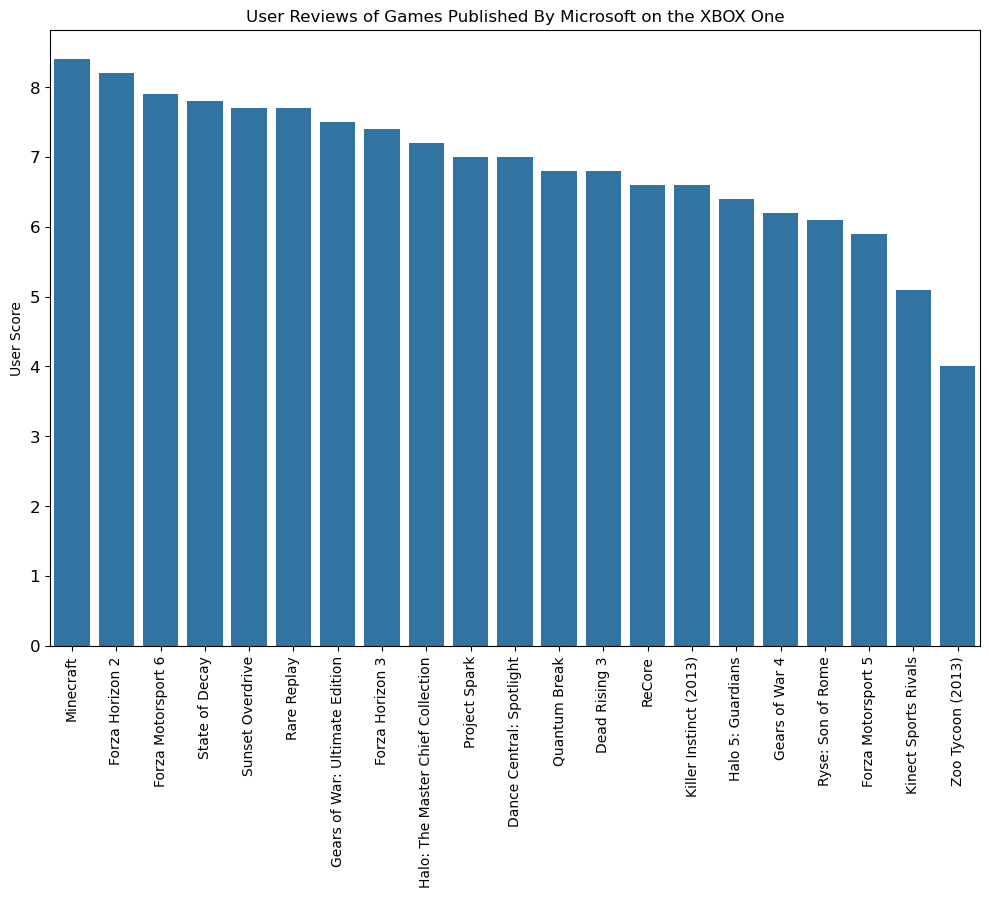

In [39]:
microsoft_count['User Score'] = pd.to_numeric(microsoft_count['User Score'], errors='coerce')

microsoft_reviews_3 = microsoft_count.sort_values(by='User Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 8))
sns.barplot(x=microsoft_reviews_3['Name'], y=microsoft_reviews_3['User Score'])
plt.title('User Reviews of Games Published By Microsoft on the XBOX One')
plt.xlabel('')
plt.ylabel('User Score')
plt.xticks(rotation=90)
plt.yticks(fontsize=12)
plt.show()

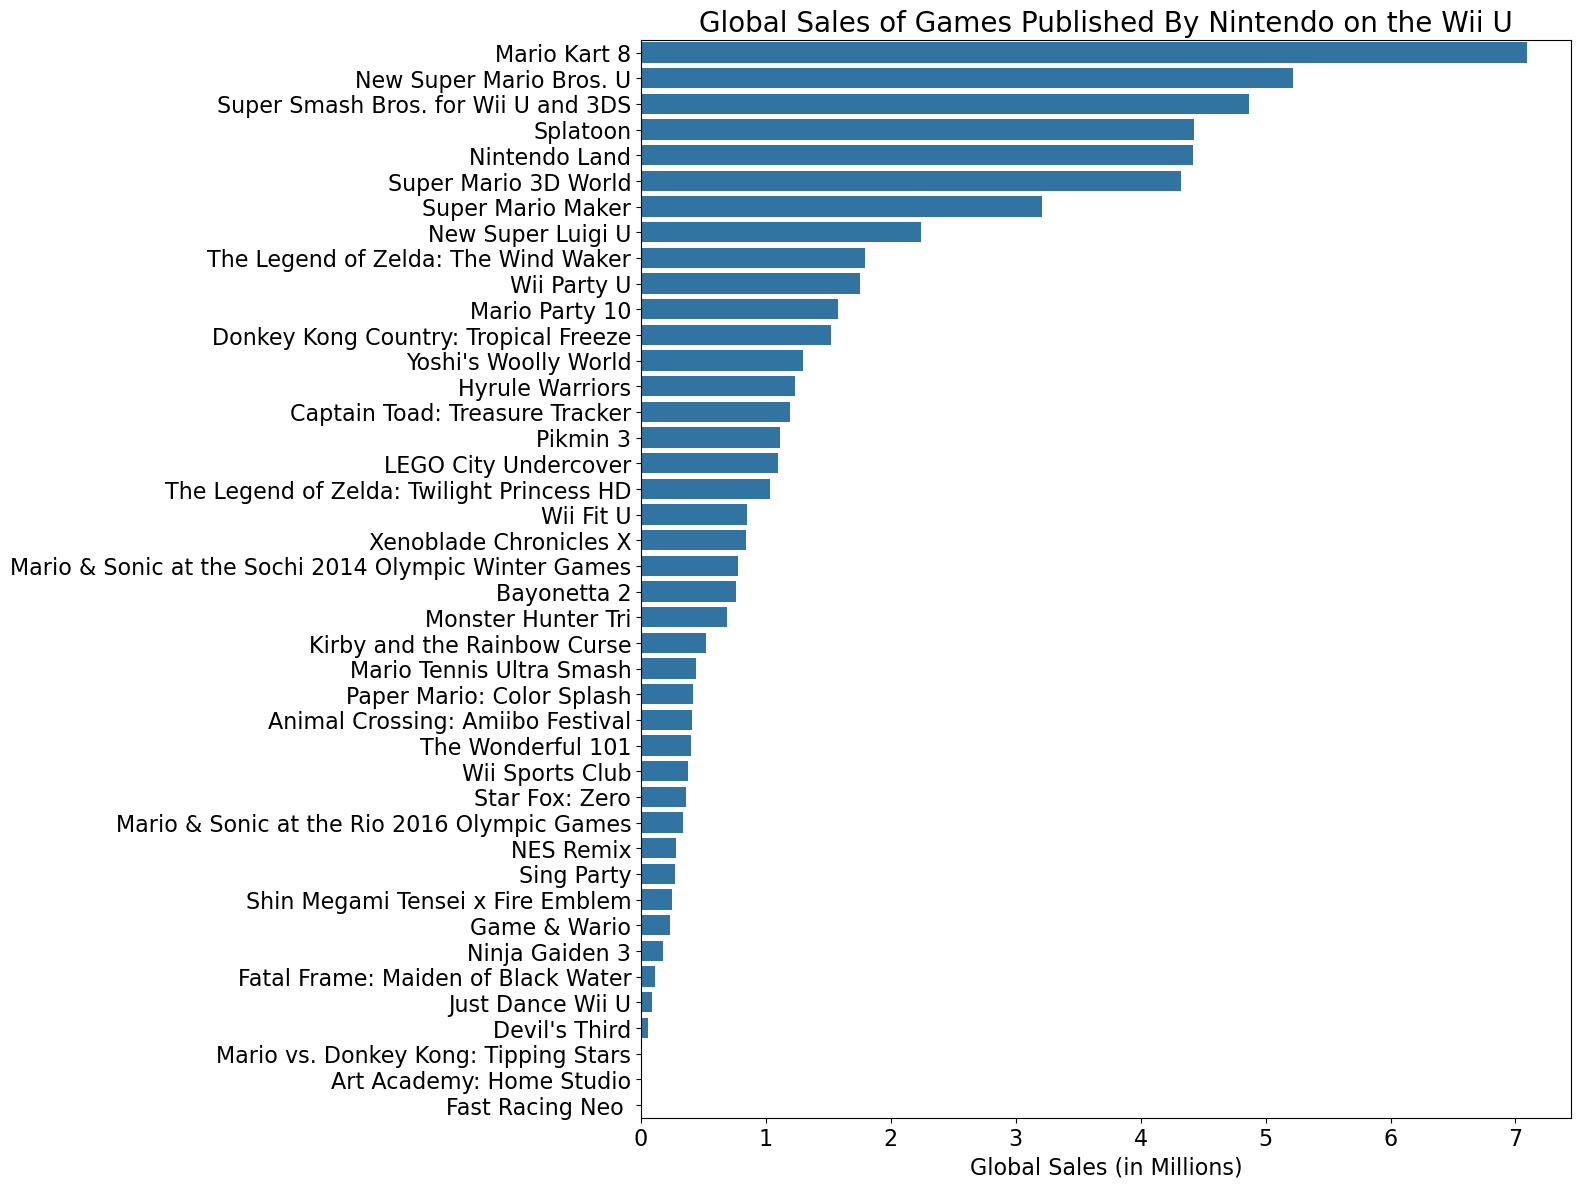

In [71]:
nintendo_reviews_4 = nintendo_count.sort_values(by='Global Sales', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 14))
sns.barplot(x=nintendo_reviews_3['Global Sales'], y=nintendo_reviews_2['Name'])
plt.title('Global Sales of Games Published By Nintendo on the Wii U', fontsize=20)
plt.xlabel('Global Sales (in Millions)', fontsize=16)
plt.ylabel('')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('Global Sales of Games Published By Nintendo on the Wii U', transparent=True, bbox_inches='tight')
plt.show()

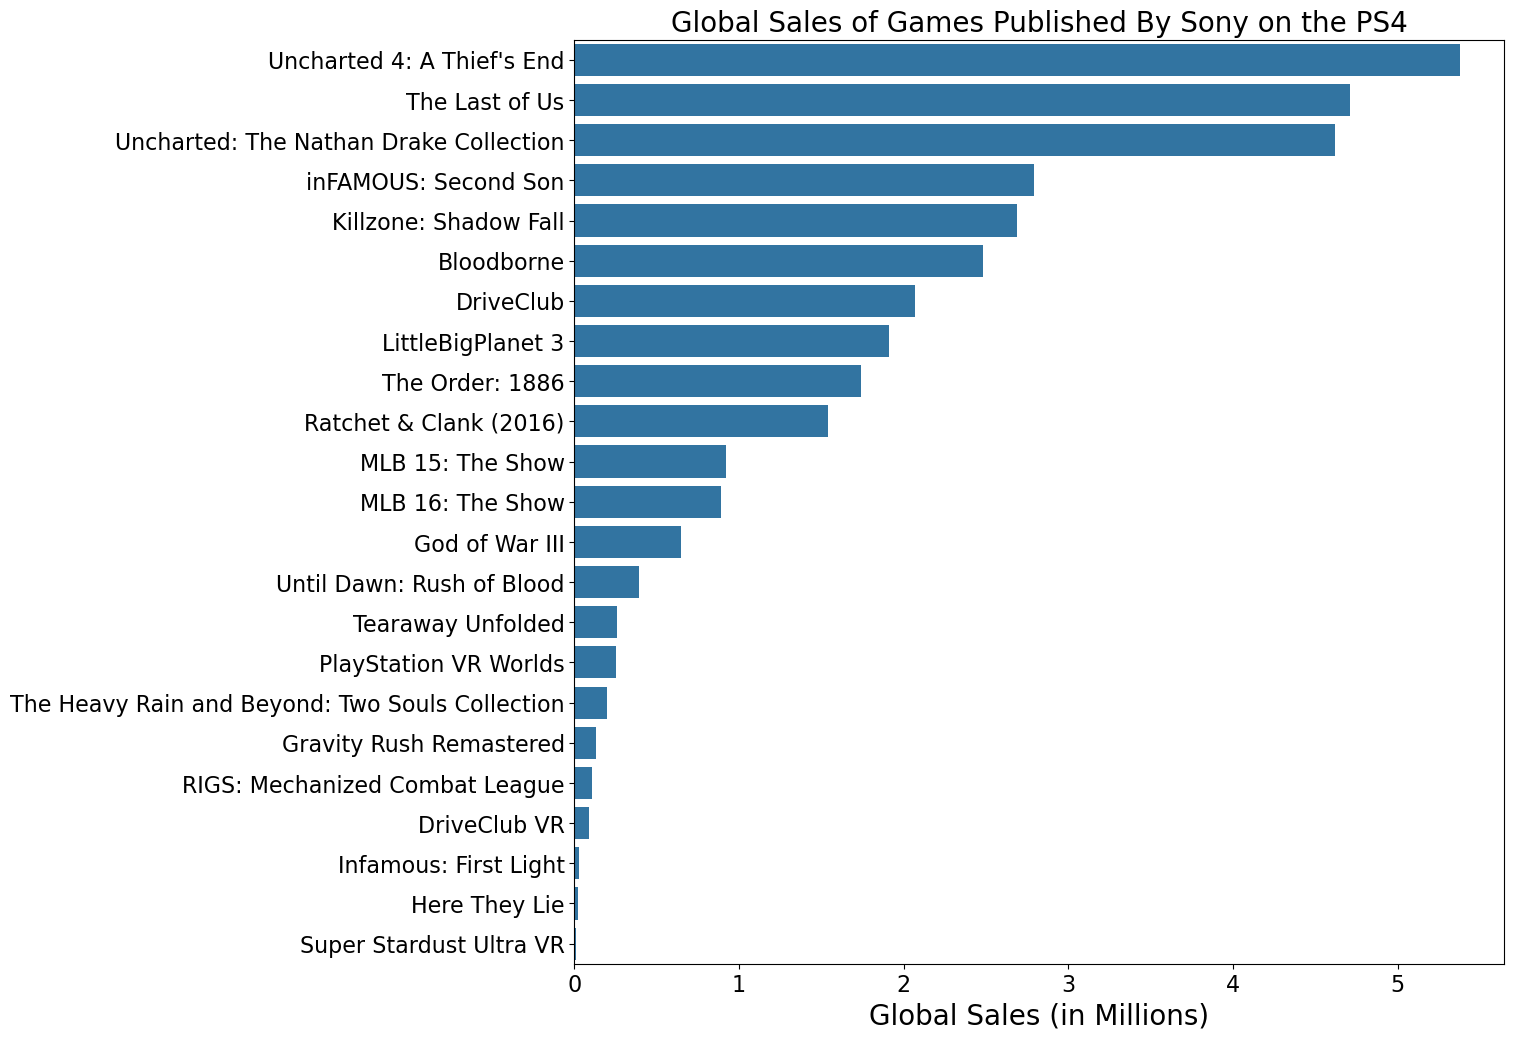

In [68]:
sony_reviews_4 = sony_count.sort_values(by='Global Sales', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 12))
sns.barplot(x=sony_reviews_3['Global Sales'], y=sony_reviews_2['Name'])
plt.title('Global Sales of Games Published By Sony on the PS4', fontsize=20)
plt.xlabel('Global Sales (in Millions)', fontsize=20)
plt.ylabel('')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('Global Sales of Games Published By Sony on the PS4', transparent=True, bbox_inches='tight')
plt.show()

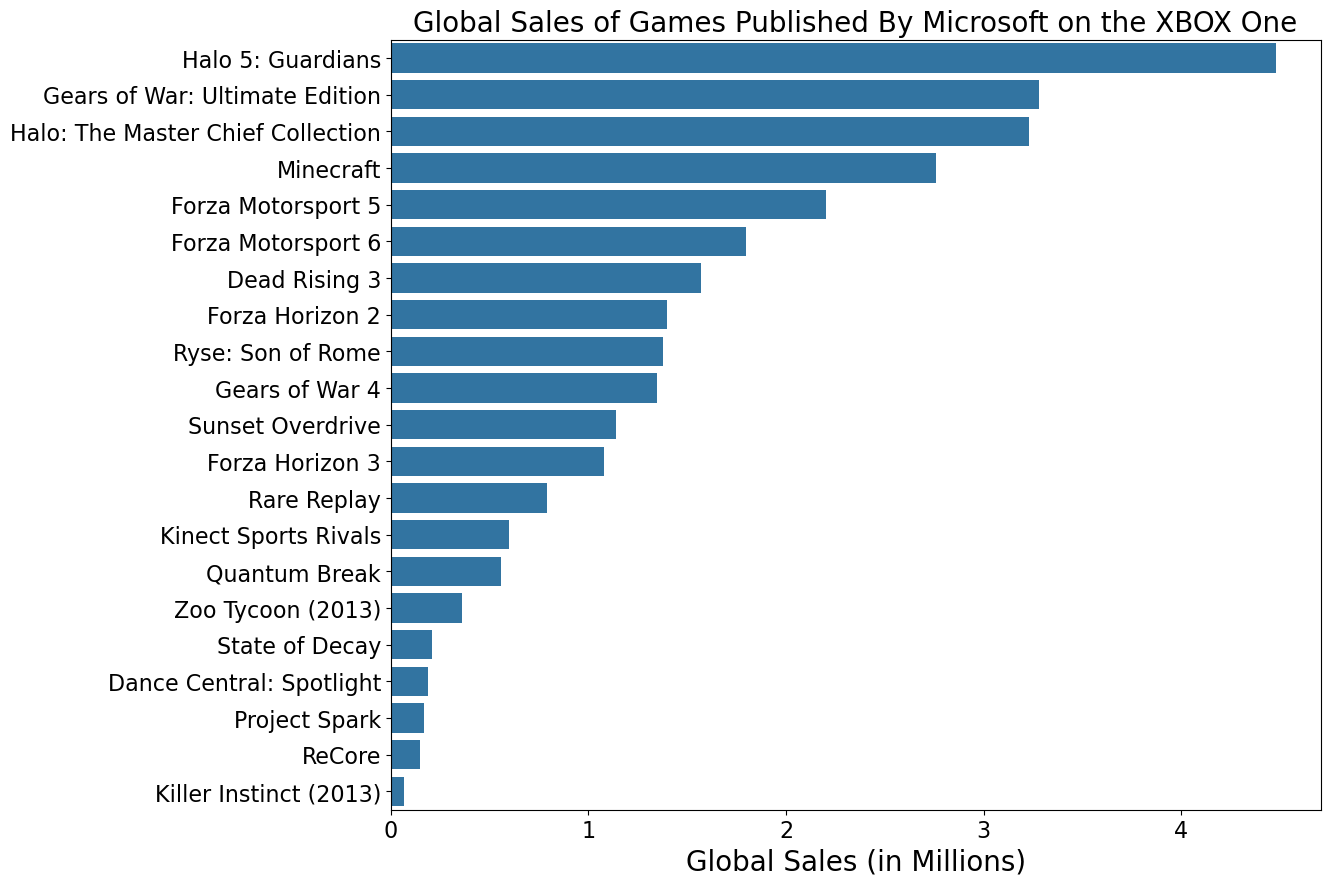

In [70]:
microsoft_reviews_4 = microsoft_count.sort_values(by='Global Sales', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 10))
sns.barplot(x=microsoft_reviews_3['Global Sales'], y=microsoft_reviews_2['Name'])
plt.title('Global Sales of Games Published By Microsoft on the XBOX One', fontsize=20)
plt.xlabel('Global Sales (in Millions)', fontsize=20)
plt.ylabel('')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('Global Sales of Games Published By Microsoft on the XBOX One', transparent=True, bbox_inches='tight')
plt.show()